# Multi-model Bayesian model averaging on CANDELS galaxies

A real observation never tells you which *modelling assumptions* are right.
Pick a single SFH family, one SSP library, one dust law, and you get a tidy
posterior — but it is conditioned on choices you cannot defend from the data
alone. This notebook does the honest thing instead: it fits the **same
galaxy** under **four genuinely different model configurations** and combines
them by **Bayesian model averaging (BMA)**, weighting each by its marginal
likelihood (evidence).

We run this for **two** CANDELS GOODS-South galaxies at $z\sim1$, and report
**per-fit timings** throughout.

| Config | SFH | SSP | Dust law | Dust emis. | Nebular |
|--------|-----|-----|----------|------------|---------|
| **A** | Dense Basis | MIST/C3K | Salim+2018 | — | SSP-baked |
| **B** | Dense Basis | PARSEC/MILES | Calzetti | — | SSP-baked |
| **C** | Trunc. skew-normal | BC03 | Kriek & Conroy | — | off |
| **D** | Double power-law | BPASS | power-law | — | off |

> **Why no dust IR emission?** At $z\sim1$ the reddest band (IRAC 8 µm) maps
> to $\sim4$ µm rest-frame — there is no far-IR photometry to constrain a
> dust-emission template, so it cannot affect the fit. It would also be a pure
> speed tax: under `WavePrecomp` the attenuated **stellar** SED is served from
> a precomputed effective-wavelength look-up table, but **additive emitters**
> (dust IR, radio, X-ray) are deliberately routed through the *exact* per-band
> filter integral (the IR template is too spiky for the LUT — see #629). That
> makes a likelihood call with dust emission more than an order of magnitude
> costlier, which dominates nested-sampling runtime (reported upstream as
> #708). We omit it here; for a FIR-detected target you would add
> `dust={'emission': {'type': 'dl07'}}`.

## Why evidence, not $\chi^2$

BMA weights are posterior model probabilities. With flat model priors,

$$
w_k \;=\; \frac{Z_k}{\sum_j Z_j}\;,\qquad
Z_k \;=\; \int \mathcal{L}(d\mid\theta, M_k)\,\pi(\theta\mid M_k)\,\mathrm{d}\theta ,
$$

where $Z_k$ is the **marginal likelihood** of model $M_k$. The evidence
automatically penalises model complexity (the Occam factor), so a more
flexible model only wins if the extra freedom is justified by the data. This
is why we fit with **nested sampling** (`"nss"`) — unlike VI/MCMC it returns a
calibrated $\log Z$ for free.

## Current public API only

Models are built with the recommended **nested-dict grammar**
(`SEDModel.build(...)`), priors with `Uniform`/`Fixed`, and we opt into the
**precompute** speed path (`approx=WavePrecomp()`) which publishes the
SSP × filter look-up table. Inference is `Fitter(model, data, noise).run("nss")`.

In [1]:
from __future__ import annotations

import time
import warnings
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")

# --- Current tengri public API ---
from tengri import (
    FIXED,
    Fitter,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    load_ssp_data,
)
from tengri.units import ab_mag_to_fnu

W0605 12:27:00.957674 2497910 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 0. Locate the repository root

Anchored on ``pyproject.toml`` so the notebook runs from any working
directory (nbconvert executes it from ``notebooks/``).

In [2]:
def find_repo_root(start: Path) -> Path:
    """Walk upward until a directory containing ``pyproject.toml`` is found."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "tengri").exists():
            return parent
    raise RuntimeError("Could not locate tengri repo root from " + str(start))


ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data"
CANDELS_DIR = ROOT / "analysis" / "hst_proposal" / "data"
FIG_DIR = ROOT / "notebooks" / "_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root : {ROOT}")
print(f"SSP grids : {DATA_DIR}")
print(f"CANDELS   : {CANDELS_DIR}")

Repo root : /Users/suchethacooray/.claude-squad/worktrees/cs/multifit_18b6135c225ba828
SSP grids : /Users/suchethacooray/.claude-squad/worktrees/cs/multifit_18b6135c225ba828/data
CANDELS   : /Users/suchethacooray/.claude-squad/worktrees/cs/multifit_18b6135c225ba828/analysis/hst_proposal/data


## 1. Parse the CANDELS GOODS-South catalogue

AB magnitudes in 17 bands (HST/ACS + WFC3 + ground-based NIR + *Spitzer*
IRAC). We map a subset onto tengri filter names.

In [3]:
# Column mapping: (mag_col_index, err_col_index, tengri_filter_name).
# Catalog layout: ID, z, then 17 (mag, e_mag) pairs, then flg1, flg2.
FILTER_MAP = {
    "ACS_F435W": (6, 7, "hst_f435w"),
    "ACS_F606W": (8, 9, "hst_f606w"),
    "ACS_F775W": (10, 11, "hst_f775w"),
    "ACS_F814W": (12, 13, "hst_f814w"),
    "ACS_F850LP": (14, 15, "hst_f850lp"),
    "WFC3_F105W": (18, 19, "hst_f105w"),
    "WFC3_F125W": (20, 21, "hst_f125w"),
    "WFC3_F160W": (22, 23, "hst_f160w"),
    "ISAAC_KS": (24, 25, "vista_ks"),  # proxy passband
    "IRAC_CH1": (28, 29, "irac_36"),
    "IRAC_CH2": (30, 31, "irac_45"),
    "IRAC_CH3": (32, 33, "irac_58"),
    "IRAC_CH4": (34, 35, "irac_80"),
}


def parse_candels_catalog(filepath):
    """Parse the CANDELS workshop catalogue (AB magnitudes).

    Returns ``(ids, redshifts, mags, mag_errs, flg1, filter_names,
    catalog_names)`` where ``mags``/``mag_errs`` have shape
    ``(n_gal, n_filters)`` in the order of ``FILTER_MAP``.
    """
    raw = np.loadtxt(filepath, dtype=str)
    ids = raw[:, 0].astype(int)
    redshifts = raw[:, 1].astype(float)
    flg1 = raw[:, -2].astype(int)

    catalog_names = list(FILTER_MAP.keys())
    filter_names = [v[2] for v in FILTER_MAP.values()]

    mags = np.full((len(ids), len(FILTER_MAP)), np.nan)
    mag_errs = np.full((len(ids), len(FILTER_MAP)), np.nan)
    for i, (_n, (mag_col, err_col, _)) in enumerate(FILTER_MAP.items()):
        mags[:, i] = raw[:, mag_col].astype(float)
        mag_errs[:, i] = raw[:, err_col].astype(float)
    return ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names


ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names = parse_candels_catalog(
    CANDELS_DIR / "CANDELS_GDSS_workshop_z1.dat"
)

# Bad-photometry flags
flagged_ids = set()
flags_file = CANDELS_DIR / "flags_z1.dat"
if flags_file.exists():
    for line in flags_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            parts = line.split()
            if len(parts) >= 2:
                flagged_ids.add(int(parts[0]))

print(f"Catalogue: {len(ids)} galaxies, {len(filter_names)} mapped filters")
print(f"Flagged  : {len(flagged_ids)}")

Catalogue: 371 galaxies, 13 mapped filters
Flagged  : 32


## 2. AB mag → $f_\nu$, and galaxy selection

We use the public `tengri.units.ab_mag_to_fnu` for the flux conversion and
pick the two highest-S/N star-forming galaxies at $z\sim1$ with $\ge10$
detected bands and clean flags.

In [4]:
NON_DETECT = 90.0  # mag > 90 ⇒ non-detection in this catalogue


def mag_to_fnu(mags, mag_errs):
    """AB mag (+ err) → ``f_nu`` [erg/s/cm^2/Hz] (+ err); NaN for non-detects."""
    detected = (mags < NON_DETECT) & (mag_errs > 0)
    fnu = np.full_like(mags, np.nan, dtype=np.float64)
    sig = np.full_like(mags, np.nan, dtype=np.float64)
    fnu[detected] = np.asarray(ab_mag_to_fnu(jnp.asarray(mags[detected])))
    sig[detected] = fnu[detected] * mag_errs[detected] * np.log(10) / 2.5
    return fnu, sig, detected


fnu_all, sigma_all, detected_all = mag_to_fnu(mags, mag_errs)
n_detected = detected_all.sum(axis=1)

z_mask = (redshifts > 0.95) & (redshifts < 1.15)
flag_mask = np.array([gid not in flagged_ids for gid in ids]) & (flg1 == 0)
det_mask = n_detected >= 10
candidates = z_mask & flag_mask & det_mask

median_snr = np.zeros(len(ids))
for i in range(len(ids)):
    if detected_all[i].any():
        median_snr[i] = np.median(fnu_all[i, detected_all[i]] / sigma_all[i, detected_all[i]])

cand_idx = np.where(candidates)[0]
cand_idx = cand_idx[np.argsort(-median_snr[cand_idx])]

# Two galaxies chosen to show the range of model-averaging behaviour:
#   CANDELS 4171  — a clean main-sequence case where several configs contribute;
#   CANDELS 17418 — a second z~1 star-former.
# (Both are among the high-S/N, well-fit candidates below.)
GAL_IDS = [4171, 17418]
SELECTED_IDX = [int(np.where(ids == g)[0][0]) for g in GAL_IDS]

print("Top candidates (z~1, ≥10 bands, clean flags):")
print(f"{'ID':>8s} {'z':>6s} {'N_det':>5s} {'med S/N':>8s}  pick")
for idx in cand_idx[:8]:
    mark = "  <--" if ids[idx] in GAL_IDS else ""
    print(f"{ids[idx]:8d} {redshifts[idx]:6.3f} {n_detected[idx]:5d} {median_snr[idx]:8.1f}{mark}")


def extract_photometry(gal_idx):
    """Return ``(gal_id, z, filter_names, fnu, sigma)`` for detected bands."""
    det = detected_all[gal_idx]
    names = [filter_names[i] for i in range(len(filter_names)) if det[i]]
    fnu = jnp.asarray(fnu_all[gal_idx, det])
    sig = jnp.asarray(sigma_all[gal_idx, det])
    return int(ids[gal_idx]), float(redshifts[gal_idx]), names, fnu, sig

Top candidates (z~1, ≥10 bands, clean flags):
      ID      z N_det  med S/N  pick
   17418  1.096    12    542.9  <--
   24497  1.031    11    542.9
   16049  1.047    13    271.4
   18160  1.095    13    271.4
   13097  1.097    13    271.4
   16435  1.094    13    217.1
   16455  1.087    13    217.1
   15775  1.097    13    217.1


## 3. Load the four SSP libraries

Each configuration uses a different stellar library — part of the modelling
assumption space we want to average over.

In [5]:
t0 = time.time()
SSP = {
    "mist": load_ssp_data(str(DATA_DIR / "ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")),
    "padova": load_ssp_data(
        str(DATA_DIR / "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
    ),
    "bc03": load_ssp_data(str(DATA_DIR / "bc03_pdva_stelib_chabrier.h5")),
    "bpass": load_ssp_data(str(DATA_DIR / "bpss_stars_c3k_a_chabrier.h5")),
}
print(f"4 SSP libraries loaded in {time.time() - t0:.1f}s")

W0605 12:27:02.207876 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:02.211656 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:02.218994 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:02.222661 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:02.244299 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


4 SSP libraries loaded in 0.3s


## 4. The four model configurations (`SEDModel.build`)

Each config is built with the nested-dict grammar. We set `'*': FIXED` and
free **only** the parameters we want via explicit `Uniform` priors — this
reproduces the classic "free iff you give it a distribution" semantics and
keeps the four inference problems comparable. `approx=WavePrecomp()` turns on
the precompute speed path.

In [6]:
# Shared priors
DB_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    "log_sfr_inst": Uniform(-2.0, 3.0),
    "tx_frac_0": Uniform(0.05, 0.95),
    "tx_frac_1": Uniform(0.05, 0.95),
    "tx_frac_2": Uniform(0.05, 0.95),
}
DUST = {"tau_bc": Uniform(0.0, 3.0), "tau_diff": Uniform(0.0, 2.0)}

# Display metadata (colours/labels match the published proposal figure)
CONFIG_ORDER = ["A", "B", "C", "D"]
SSP_FOR = {"A": "mist", "B": "padova", "C": "bc03", "D": "bpass"}
COLORS = {"A": "#1b9e77", "B": "#d95f02", "C": "#7570b3", "D": "#e7298a"}
BMA_COLOR = "0.1"
LABELS = {
    "A": "Dense Basis / MIST / Salim / neb.",
    "B": "Dense Basis / Padova / Calzetti",
    "C": r"Trunc. Skew-Normal / BC03 / K\&C",
    "D": "Double Power Law / BPASS / power-law",
}


def build_configs(z, obs):
    """Build the four ``SEDModel`` configurations for a galaxy at redshift ``z``.

    Returns ``{config_letter: SEDModel}``. Each model opts into the precompute
    (``WavePrecomp``) speed path.
    """
    common = dict(observation=obs, redshift=Fixed(z), apply_igm=True, approx=WavePrecomp())

    model_a = SEDModel.build(
        ssp_data=SSP["mist"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "salim_sbl18", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_b = SEDModel.build(
        ssp_data=SSP["padova"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_c = SEDModel.build(
        ssp_data=SSP["bc03"],
        sfh={
            "type": "tsnorm",
            "*": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            "log_total_mass": Uniform(8.0, 12.0),
            "peak_lbt_gyr": Uniform(0.5, 12.0),
            "width_gyr": Uniform(0.2, 5.0),
            "skew": Uniform(-1.0, 1.0),
            "trunc": Uniform(1.0, 10.0),
        },
        dust={"type": "two_component", "law_bc": "kriek_conroy", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    model_d = SEDModel.build(
        ssp_data=SSP["bpass"],
        sfh={
            "type": "dpl",
            "*": FIXED,
            "met_logzsol": Fixed(-0.3),
            "alpha": Uniform(0.5, 5.0),
            "beta": Uniform(0.3, 3.0),
            "tau_gyr": Uniform(0.5, 13.0),
            "log_total_mass": Uniform(8.0, 12.0),
        },
        dust={"type": "two_component", "law_bc": "power_law", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    return {"A": model_a, "B": model_b, "C": model_c, "D": model_d}

## 5. Fit every (galaxy × config) with nested sampling

Nested slice sampling (`"nss"`), `n_live=500`, using the catalogue flux
uncertainties directly. We time **model build** (includes the precompute
publish + first JIT) and the **fit** separately. With the real (small) errors
each model is tightly constrained, so the per-model posteriors separate
cleanly — the evidence then decides how to weight them.

In [7]:
N_LIVE = 500
N_POST = 1000

galaxies = {}  # gal_id -> dict(z, names, fnu, sigma, models, posteriors, timings)

for gal_idx in SELECTED_IDX:
    gal_id, z, names, fnu, sigma = extract_photometry(gal_idx)
    print(
        f"\n{'#' * 64}\n# Galaxy CANDELS {gal_id}  (z = {z:.3f}, {len(names)} bands)\n{'#' * 64}"
    )

    obs = Observation(photometry=Photometry.from_names(names))

    t_build = time.time()
    models = build_configs(z, obs)
    build_s = time.time() - t_build
    print(f"  built 4 models in {build_s:.1f}s")

    posteriors, fit_timings = {}, {}
    for cfg in CONFIG_ORDER:
        model = models[cfg]
        n_free = len(model.spec.free_params)
        key = jax.random.PRNGKey(abs(hash((gal_id, cfg))) % (2**31))
        t_fit = time.time()
        post = Fitter(model, fnu, sigma).run(
            "nss", key=key, n_live=N_LIVE, n_posterior_samples=N_POST, verbose=False
        )
        dt = time.time() - t_fit
        posteriors[cfg] = post
        fit_timings[cfg] = dt
        print(f"  [{cfg}] D={n_free:2d}  fit {dt:6.1f}s  logZ = {post.log_evidence:8.1f}")

    galaxies[gal_id] = dict(
        z=z,
        names=names,
        fnu=np.asarray(fnu),
        sigma=np.asarray(sigma),
        models=models,
        posteriors=posteriors,
        build_s=build_s,
        fit_timings=fit_timings,
    )

print("\nAll fits complete.")


################################################################
# Galaxy CANDELS 4171  (z = 1.032, 11 bands)
################################################################


W0605 12:27:02.494781 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:02.526552 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:27:02.889153 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:02.892065 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:02.951095 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:03.017151 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:03.022365 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:03.025029 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:03.028859 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:03.032184 2497786 pjrt_executable.cc:638] Assume v

W0605 12:27:03.149011 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:27:03.218089 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  built 4 models in 0.4s


...

W0605 12:32:36.999321 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:37.097325 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:32:51.884677 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:32:52.319094 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  [D] D= 6  fit   17.6s  logZ = -14633.0

All fits complete.


W0605 12:32:53.052357 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.054594 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.056906 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.081867 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.150920 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.162415 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 6. Timing summary

In [8]:
print(
    f"{'Galaxy':>14s} {'build':>7s} "
    + " ".join(f"{'fit ' + c:>9s}" for c in CONFIG_ORDER)
    + f" {'total':>8s}"
)
for gal_id, g in galaxies.items():
    fits = " ".join(f"{g['fit_timings'][c]:9.1f}" for c in CONFIG_ORDER)
    total = g["build_s"] + sum(g["fit_timings"].values())
    print(f"CANDELS {gal_id:>6d} {g['build_s']:7.1f} {fits} {total:8.1f}")
print("(seconds; build includes precompute publish + first JIT compile)")

        Galaxy   build     fit A     fit B     fit C     fit D    total
CANDELS   4171     0.4      57.7      47.2      40.0      14.1    159.3
CANDELS  17418     0.4      51.3      54.1      67.2      17.6    190.7
(seconds; build includes precompute publish + first JIT compile)


## 7. Posterior predictions + Bayesian model averaging

For each fit we draw posterior SEDs, SFHs, and derived $(M_\star,
\mathrm{SFR})$. BMA weights come from the evidences; the BMA predictive is an
evidence-weighted pool of the per-config draws.

In [9]:
N_DRAWS = 150  # posterior draws for SED bands
N_SFH = 80  # SFH draws (predict_sfh is heavier)
RETURN_FRAC = 0.6  # surviving / formed mass (Chabrier; Madau & Dickinson 2014)
WAVE_SPEC = np.logspace(np.log10(3000), np.log10(1e5), 300)  # observed-frame Å
rng = np.random.default_rng(0)

# Effective wavelengths [Å] of the catalogue bands (for placing data + scaling).
WAVE_EFF = {
    "hst_f435w": 4328, "hst_f606w": 5921, "hst_f775w": 7693, "hst_f814w": 8057,
    "hst_f850lp": 9036, "hst_f105w": 10552, "hst_f125w": 12486, "hst_f160w": 15369,
    "vista_ks": 21440, "irac_36": 35634, "irac_45": 45110, "irac_58": 57593, "irac_80": 79594,
}  # fmt: skip


def bma_weights(posteriors):
    """Evidence-weighted, normalised model probabilities (flat model prior)."""
    logz = np.array([posteriors[c].log_evidence for c in CONFIG_ORDER])
    w = np.exp(logz - logz.max())
    return w / w.sum()


def bin_to_grid(wave, y, grid):
    """Downsample ``y(wave)`` onto ``grid`` by mean within log-spaced bins.

    A binned mean (rather than point interpolation) keeps narrow nebular
    emission lines at the *resolution of the plot grid* — so they appear as
    modest bumps rather than aliased full-height spikes, matching a coarsely
    sampled spectrum.
    """
    edges = np.empty(len(grid) + 1)
    edges[1:-1] = np.sqrt(grid[1:] * grid[:-1])
    edges[0], edges[-1] = grid[0], grid[-1]
    tot, _ = np.histogram(wave, bins=edges, weights=y)
    cnt, _ = np.histogram(wave, bins=edges)
    out = np.divide(tot, cnt, out=np.full_like(tot, np.nan), where=cnt > 0)
    empty = ~np.isfinite(out)
    if empty.any():  # fill any empty bins by interpolation from filled ones
        out[empty] = np.interp(grid[empty], grid[~empty], out[~empty])
    return out


def vmap_chunked(fn, batch, n, chunk=16):
    """``jax.vmap`` ``fn`` over an ``n``-draw batch in memory-bounded chunks.

    vmapping all draws at once materialises every draw's forward-pass
    intermediates simultaneously and can OOM; chunking caps peak memory while
    still collapsing the Python loop into a handful of vectorised dispatches.
    Results are concatenated along the draw axis (works for tuple / NamedTuple /
    dict returns).
    """
    parts = []
    for start in range(0, n, chunk):
        sub = {k: v[start : start + chunk] for k, v in batch.items()}
        parts.append(jax.vmap(fn)(sub))
    return jax.tree_util.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *parts)


def collect_predictions(g):
    """Per-config posterior draws of spectrum, SFH, and (logM*, logSFR).

    The continuous SED comes from ``predict_obs_sed`` (observed-frame rest L_nu
    on each SSP's native grid). We rescale L_nu to observed ``f_nu`` with the
    distance factor anchored to ``predict_photometry`` (a pure constant,
    4*pi*d_L^2 / (1+z)), then bin every config onto the common ``WAVE_SPEC``
    grid so the four can be pooled for the BMA predictive.

    Posterior draws are evaluated with ``jax.vmap`` over the sample batch (one
    vectorised forward call per config) rather than a Python loop — same
    numbers, ~10x faster.
    """
    weff = np.array([WAVE_EFF[n] for n in g["names"]])
    spec, sfh, props = {}, {}, {}
    for cfg in CONFIG_ORDER:
        model = g["models"][cfg]
        samples = g["posteriors"][cfg].samples
        n_avail = next(iter(samples.values())).shape[0]
        n_use = min(N_DRAWS, n_avail)
        batch = {k: v[:n_use] for k, v in samples.items()}

        # SED: chunked-vmapped predict_obs_sed over the whole draw batch.
        wave_b, lnu_b = vmap_chunked(model.predict_obs_sed, batch, n_use)
        wave_nat, lnu_b = np.asarray(wave_b[0]), np.asarray(lnu_b)
        # L_nu -> observed f_nu scale factor (cosmology-only constant; from draw 0).
        phot0 = np.asarray(model.predict_photometry({k: v[0] for k, v in batch.items()}))
        flux_factor = np.median(phot0 / np.interp(weff, wave_nat, lnu_b[0]))
        spec[cfg] = np.array(
            [bin_to_grid(wave_nat, lnu_b[i] * flux_factor, WAVE_SPEC) for i in range(n_use)]
        )

        # SFH: chunked-vmapped predict_sfh over the (possibly smaller) SFH batch.
        n_sfh = min(n_use, N_SFH)
        sfh_b = vmap_chunked(model.predict_sfh, {k: v[:n_sfh] for k, v in samples.items()}, n_sfh)
        sfh[cfg] = {"t_gyr": np.asarray(sfh_b["t_gyr"][0]), "sfr": np.asarray(sfh_b["sfr_full"])}

        # Derived (M*, SFR): chunked-vmapped predict_sfh_quantities over the batch.
        q = vmap_chunked(model.predict_sfh_quantities, batch, n_use)
        logm = np.asarray(q.stellar_mass) * RETURN_FRAC
        props[cfg] = {
            "log_mass": np.log10(np.maximum(logm, 1e-30)),
            "log_sfr": np.log10(np.maximum(np.asarray(q.sfr_100myr), 1e-30)),
        }
    return spec, sfh, props


for gal_id, g in galaxies.items():
    g["weights"] = bma_weights(g["posteriors"])
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    wstr = "  ".join(f"{c}={w:.2f}" for c, w in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id}  BMA weights:  {wstr}")

W0605 12:32:53.363643 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.425509 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.428449 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:32:53.755753 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.758392 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:53.760958 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:32:55.817652 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:55.820518 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:55.823246 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:55.853846 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:55.857127 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:32:56.087640 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:56.116480 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 12:32:56.139651 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:32:56.574905 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 12:33:47.104774 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:33:53.954359 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:34:00.467703 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 12:34:04.968718 2497786 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


CANDELS 17418  BMA weights:  A=1.00  B=0.00  C=0.00  D=0.00


## 8. Figures — one galaxy per figure

Each galaxy gets its **own** three-panel figure (publication style via
`scienceplots`): **(a)** observed photometry (red) + per-config posterior SEDs
+ the BMA predictive (black); **(b)** inferred SFHs with the model legend;
**(c)** the $M_\star$–SFR posterior as filled 68/95% credible contours, with
the evidence-weighted BMA in black. The BMA band/contour is broader than any
single model — it folds in the *between-model* uncertainty the individual fits
cannot see.

In [10]:
import scienceplots

plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "figure.dpi": 220,
        "savefig.dpi": 400,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.3,
        "ytick.minor.width": 0.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

POINT_COLOR = "#e8000b"  # red photometry markers (matches proposal figure)
# Approximate filter half-widths [Å] for the photometry x error bars.
FILTER_HALFWIDTH = {
    "hst_f435w": 500, "hst_f606w": 1100, "hst_f775w": 750, "hst_f814w": 1250,
    "hst_f850lp": 600, "hst_f105w": 1500, "hst_f125w": 1500, "hst_f160w": 1400,
    "vista_ks": 1600, "irac_36": 3800, "irac_45": 5100, "irac_58": 7100, "irac_80": 14300,
}  # fmt: skip


def pool(per_cfg, weights, total):
    """Evidence-weighted pool of per-config draw arrays (axis 0 = draws)."""
    out = []
    for cfg, w in zip(CONFIG_ORDER, weights):
        arr = per_cfg[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(arr), size=min(n, len(arr)), replace=True)
        out.append(arr[idx])
    return np.concatenate(out, axis=0)


def pool_pairs(per_cfg_x, per_cfg_y, weights, total):
    """Evidence-weighted pool of *paired* (x, y) draws — one index set per config.

    Keeps the (M*, SFR) correlation intact; pooling x and y with independent
    ``rng.choice`` calls would decorrelate them and misplace the BMA contour.
    """
    xs, ys = [], []
    for cfg, w in zip(CONFIG_ORDER, weights):
        x, y = per_cfg_x[cfg], per_cfg_y[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(x), size=min(n, len(x)), replace=True)
        xs.append(x[idx])
        ys.append(y[idx])
    return np.concatenate(xs), np.concatenate(ys)


def filled_kde(ax, x, y, color, *, zorder=2, bma=False):
    """Filled 68/95% credible contours of a 2-D KDE (point if degenerate)."""
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    if len(x) < 5 or x.std() < 1e-6 or y.std() < 1e-6:
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except np.linalg.LinAlgError:
        return
    xg = np.linspace(x.mean() - 4 * x.std(), x.mean() + 4 * x.std(), 120)
    yg = np.linspace(y.mean() - 4 * y.std(), y.mean() + 4 * y.std(), 120)
    XG, YG = np.meshgrid(xg, yg)
    ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
    zs = np.sort(ZG.ravel())[::-1]
    zc = np.cumsum(zs) / zs.sum()
    l68, l95 = zs[np.searchsorted(zc, 0.68)], zs[np.searchsorted(zc, 0.95)]
    zmax = ZG.max()
    if not (l95 < l68 < zmax):
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    a95, a68 = (0.45, 0.85) if bma else (0.30, 0.65)
    ax.contourf(
        XG, YG, ZG, levels=[l95, l68, zmax], colors=[color, color], alpha=a95, zorder=zorder
    )
    ax.contourf(XG, YG, ZG, levels=[l68, zmax], colors=[color], alpha=a68 - a95, zorder=zorder)
    ax.contour(
        XG, YG, ZG, levels=[l95], colors="k" if bma else [color],
        linewidths=0.7 if bma else 0.4, alpha=0.9, zorder=zorder + 0.1,
    )  # fmt: skip


def plot_galaxy(gal_id):
    """Render the three-panel multi-model + BMA figure for one galaxy."""
    g = galaxies[gal_id]
    w = g["weights"]
    fig = plt.figure(figsize=(6.5, 1.65))
    gs = GridSpec(
        1, 3, figure=fig, width_ratios=[1.15, 1.0, 1.0],
        wspace=0.38, left=0.08, right=0.98, bottom=0.18, top=0.88,
    )  # fmt: skip

    # ---- (a) SED ----
    ax = fig.add_subplot(gs[0])
    for cfg in CONFIG_ORDER:
        d = g["spec"][cfg]
        ax.fill_between(WAVE_SPEC, np.percentile(d, 16, 0), np.percentile(d, 84, 0),
                        color=COLORS[cfg], alpha=0.12, lw=0)  # fmt: skip
        ax.plot(WAVE_SPEC, np.median(d, 0), "-", color=COLORS[cfg], lw=0.8, alpha=0.85)
    bma = pool(g["spec"], w, 300)
    ax.fill_between(WAVE_SPEC, np.percentile(bma, 16, 0), np.percentile(bma, 84, 0),
                    color=BMA_COLOR, alpha=0.10, lw=0)  # fmt: skip
    ax.plot(WAVE_SPEC, np.median(bma, 0), "-", color=BMA_COLOR, lw=1.5, alpha=0.95, zorder=5)
    wobs = np.array([WAVE_EFF[n] for n in g["names"]])
    xerr = np.array([FILTER_HALFWIDTH.get(n, 500) for n in g["names"]])
    ax.errorbar(wobs, g["fnu"], yerr=g["sigma"], xerr=xerr, fmt="o", ms=3.5,
                color=POINT_COLOR, ecolor="0.3", elinewidth=0.7, capsize=0,
                markeredgewidth=0, zorder=10)  # fmt: skip
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(3200, 1e5)
    fnu_pos = g["fnu"][g["fnu"] > 0]
    ax.set_ylim(0.3 * fnu_pos.min(), 4 * fnu_pos.max())  # frame on the data
    ax.set_xlabel(r"$\lambda_\mathrm{obs}$ [$\AA$]")
    ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
    ax.text(0.04, 0.93, r"$\bf{(a)}$", transform=ax.transAxes, fontsize=8, va="top")
    ax.text(
        0.96, 0.08, f"CANDELS {gal_id}\n$z = {g['z']:.3f}$", transform=ax.transAxes,
        fontsize=6, ha="right", va="bottom",
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "0.7", "lw": 0.4, "alpha": 0.9},
    )  # fmt: skip

    # ---- (b) SFH + legend ----
    ax = fig.add_subplot(gs[1])
    maxes = []
    for cfg in CONFIG_ORDER:
        t, sfr = g["sfh"][cfg]["t_gyr"], g["sfh"][cfg]["sfr"]
        med = np.median(sfr, 0)
        ax.fill_between(t, np.percentile(sfr, 16, 0), np.percentile(sfr, 84, 0),
                        color=COLORS[cfg], alpha=0.15, lw=0)  # fmt: skip
        ax.plot(t, med, "-", color=COLORS[cfg], lw=0.9, alpha=0.9)
        maxes.append(np.max(med[t < 5]))
    t_common = g["sfh"]["A"]["t_gyr"]
    bma_sfr = pool({c: g["sfh"][c]["sfr"] for c in CONFIG_ORDER}, w, 200)
    ax.fill_between(t_common, np.percentile(bma_sfr, 16, 0), np.percentile(bma_sfr, 84, 0),
                    color=BMA_COLOR, alpha=0.15, lw=0)  # fmt: skip
    ax.plot(t_common, np.median(bma_sfr, 0), "-", color=BMA_COLOR, lw=1.8, alpha=0.95)
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1.5 * max(maxes))
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]")
    ax.text(0.04, 0.93, r"$\bf{(b)}$", transform=ax.transAxes, fontsize=8, va="top")

    # ---- (c) M*-SFR ----
    ax = fig.add_subplot(gs[2])
    for cfg in CONFIG_ORDER:
        filled_kde(ax, g["props"][cfg]["log_mass"], g["props"][cfg]["log_sfr"],
                   COLORS[cfg], zorder=3)  # fmt: skip
    bm, bs = pool_pairs(
        {c: g["props"][c]["log_mass"] for c in CONFIG_ORDER},
        {c: g["props"][c]["log_sfr"] for c in CONFIG_ORDER},
        w,
        2000,
    )
    filled_kde(ax, bm, bs, BMA_COLOR, zorder=6, bma=True)
    ax.set_xlabel(r"$\log\,(M_\star\,/\,M_\odot)$")
    ax.set_ylabel(r"$\log\,(\mathrm{SFR}_{100}\,/\,M_\odot\,\mathrm{yr}^{-1})$")
    ax.text(0.04, 0.93, r"$\bf{(c)}$", transform=ax.transAxes, fontsize=8, va="top")

    # Shared legend across the top, two rows (3 + 2 entries).
    handles = [Line2D([0], [0], color=COLORS[c], lw=1.6, label=LABELS[c]) for c in CONFIG_ORDER]
    handles.append(Line2D([0], [0], color=BMA_COLOR, lw=2.5, label="Bayesian Model Avg."))
    fig.legend(
        handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=3,
        fontsize=6.5, frameon=True, edgecolor="0.7", framealpha=0.95,
        handlelength=1.6, columnspacing=1.4, handletextpad=0.4, labelspacing=0.3,
    )  # fmt: skip

    fig.savefig(FIG_DIR / f"multimodel_bma_candels_{gal_id}.png", dpi=400, bbox_inches="tight")
    plt.show()
    wstr = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    print(f"CANDELS {gal_id}: BMA weights  {wstr}")

### CANDELS 4171

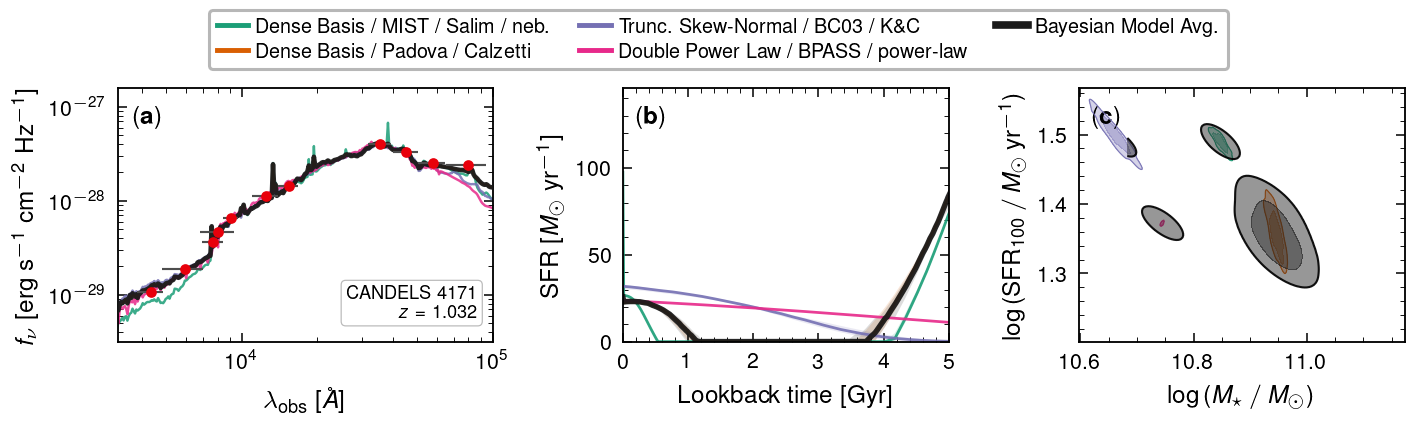

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [11]:
plot_galaxy(4171)

### CANDELS 17418

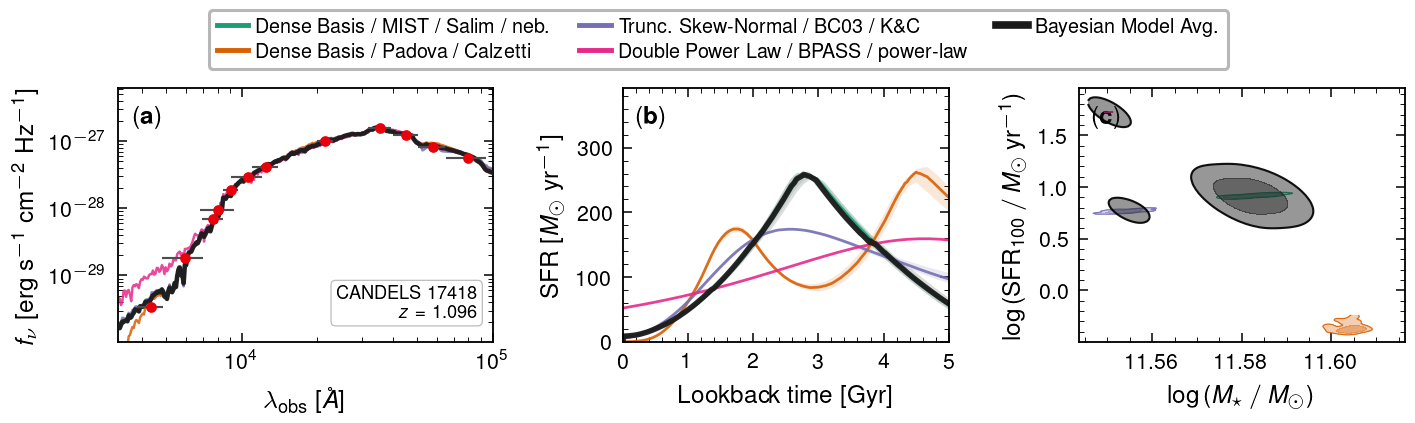

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [12]:
plot_galaxy(17418)

## 9. Takeaways

- **The evidence picks favourites.** The BMA weights are rarely uniform — one
  or two configurations usually dominate $\log Z$, and the average is pulled
  toward them while still retaining the others' spread.
- **The models genuinely disagree.** Panel (c) shows four tight but
  *separated* $M_\star$–SFR clusters: swapping SSP library, SFH family, or dust
  law moves the inferred stellar mass by a few tenths of a dex even at fixed
  photometry. That systematic spread is exactly what BMA exposes.
- **Same public surface throughout.** Every model came from
  `SEDModel.build(...)` with the nested-dict grammar; the only knob that
  changed for speed was `approx=WavePrecomp()`. Inference was the one-liner
  `Fitter(model, data, noise).run("nss", ...)`, whose `log_evidence` is what
  makes the averaging principled.